In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
loan = pd.read_csv('loan-train.csv')
loan.shape

(1614, 13)

In [5]:
loan.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [6]:
loan.info()

<class 'pandas.DataFrame'>
RangeIndex: 1614 entries, 0 to 1613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            1614 non-null   str    
 1   Gender             1601 non-null   str    
 2   Married            1611 non-null   str    
 3   Dependents         1599 non-null   str    
 4   Education          1614 non-null   str    
 5   Self_Employed      1582 non-null   str    
 6   ApplicantIncome    1614 non-null   int64  
 7   CoapplicantIncome  1614 non-null   float64
 8   LoanAmount         1592 non-null   float64
 9   Loan_Amount_Term   1600 non-null   float64
 10  Credit_History     1564 non-null   float64
 11  Property_Area      1614 non-null   str    
 12  Loan_Status        1614 non-null   str    
dtypes: float64(4), int64(1), str(8)
memory usage: 221.3 KB


In [7]:
loan.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,1614.000000,1614.000000,1592.000000,1600.000000,1564.00000
mean,8746.304833,3658.722999,218.846734,290.475000,0.63555
std,6249.885122,3291.745935,133.623293,81.899735,0.48143
min,150.000000,0.000000,9.000000,12.000000,0.00000
25%,3675.250000,986.250000,112.000000,240.000000,0.00000
50%,7045.000000,2941.500000,180.000000,360.000000,1.00000
75%,13251.000000,5893.000000,324.000000,360.000000,1.00000
max,81000.000000,41667.000000,700.000000,480.000000,1.00000


In [8]:
loan.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')

In [9]:
loan.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [10]:
print("Duplicate rows:", loan.duplicated().sum())
loan = loan.drop_duplicates()

Duplicate rows: 0


In [11]:
loan['Gender'] = loan['Gender'].fillna(loan['Gender'].mode()[0])

In [12]:
loan['Married'] = loan['Married'].fillna(loan['Married'].mode()[0])


In [13]:
loan['Dependents'] = loan['Dependents'].fillna(loan["Dependents"].mode()[0])

In [14]:
loan['Self_Employed'] = loan['Self_Employed'].fillna(loan["Self_Employed"].mode()[0])

In [15]:
loan['LoanAmount'] = loan['LoanAmount'].fillna(loan["LoanAmount"].mode()[0])

In [16]:
loan['Loan_Amount_Term'] = loan['Loan_Amount_Term'].fillna(loan["Loan_Amount_Term"].mode()[0])

In [17]:
loan['Credit_History'] = loan['Credit_History'].fillna(loan["Credit_History"].mode()[0])

In [18]:
loan.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [19]:
loan['Dependents'] = loan['Dependents'].replace('3+', '3')

In [20]:
loan['Dependents'] = loan['Dependents'].astype(int)
loan['Credit_History'] = loan['Credit_History'].astype(int)

In [21]:
sns.set(style="whitegrid")

In [22]:
categorical_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']

Gender
Male      993
Female    621
Name: count, dtype: int64


C:\Users\Hamza\AppData\Local\Temp\ipykernel_9556\405469035.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=loan, palette='Set2')


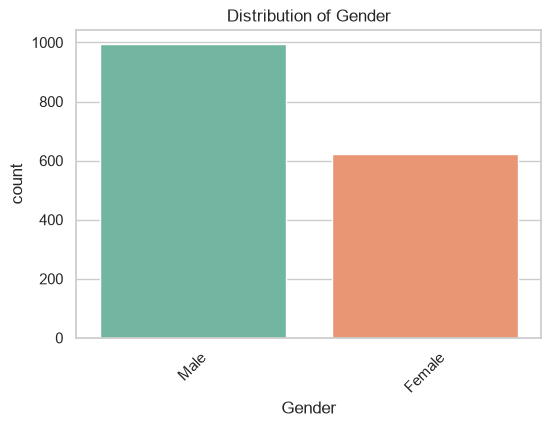

Married
Yes    928
No     686
Name: count, dtype: int64


C:\Users\Hamza\AppData\Local\Temp\ipykernel_9556\405469035.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=loan, palette='Set2')


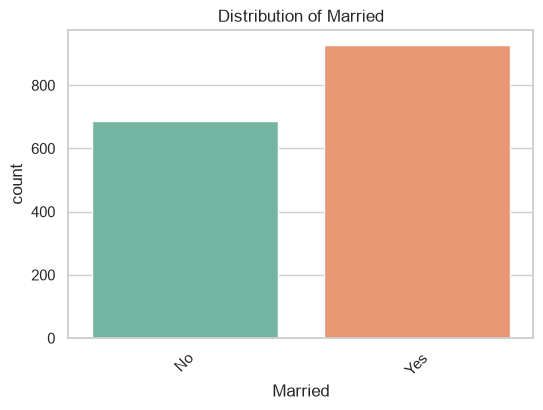

Dependents
0    634
1    341
2    336
3    303
Name: count, dtype: int64


C:\Users\Hamza\AppData\Local\Temp\ipykernel_9556\405469035.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=loan, palette='Set2')


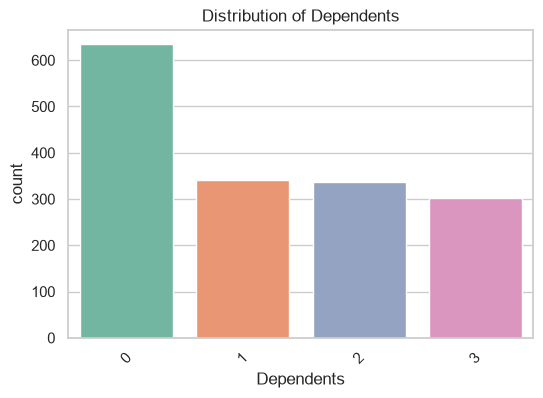

Education
Graduate        952
Not Graduate    662
Name: count, dtype: int64


C:\Users\Hamza\AppData\Local\Temp\ipykernel_9556\405469035.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=loan, palette='Set2')


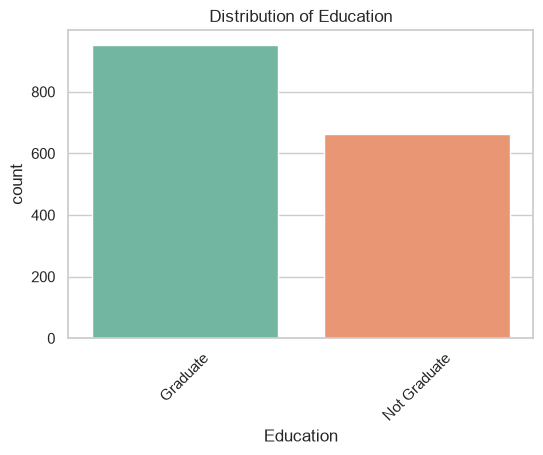

Self_Employed
No     1031
Yes     583
Name: count, dtype: int64


C:\Users\Hamza\AppData\Local\Temp\ipykernel_9556\405469035.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=loan, palette='Set2')


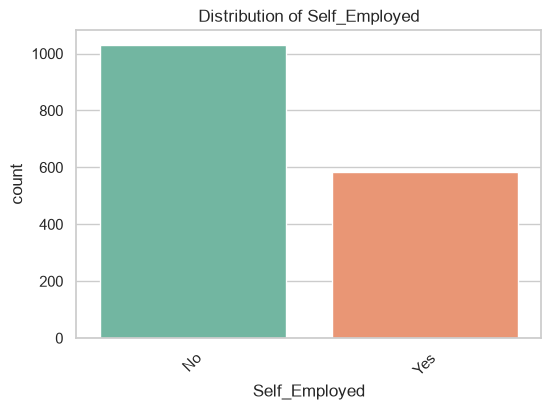

Property_Area
Urban        549
Semiurban    545
Rural        520
Name: count, dtype: int64


C:\Users\Hamza\AppData\Local\Temp\ipykernel_9556\405469035.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=loan, palette='Set2')


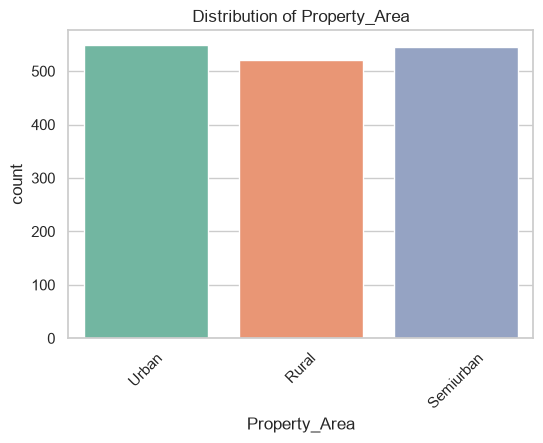

Loan_Status
Y    915
N    699
Name: count, dtype: int64


C:\Users\Hamza\AppData\Local\Temp\ipykernel_9556\405469035.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=loan, palette='Set2')


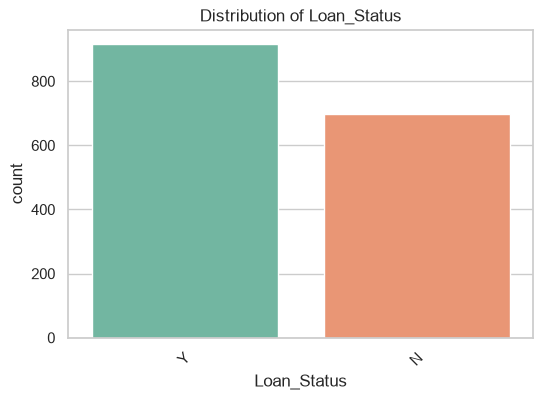

In [23]:
for col in categorical_cols:
    print(loan[col].value_counts())
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=loan, palette='Set2')
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

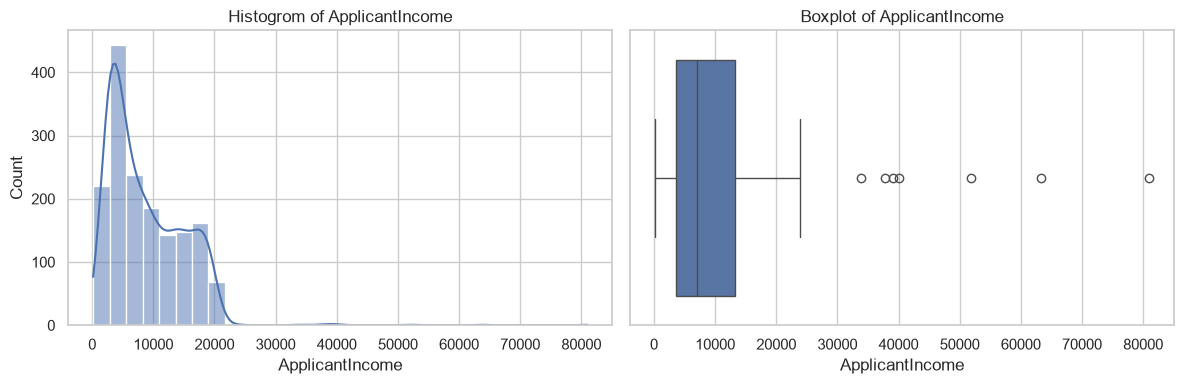

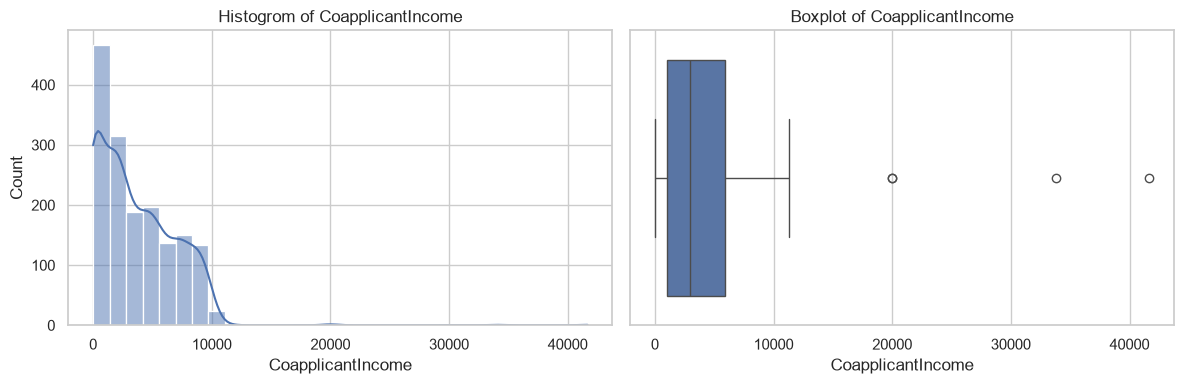

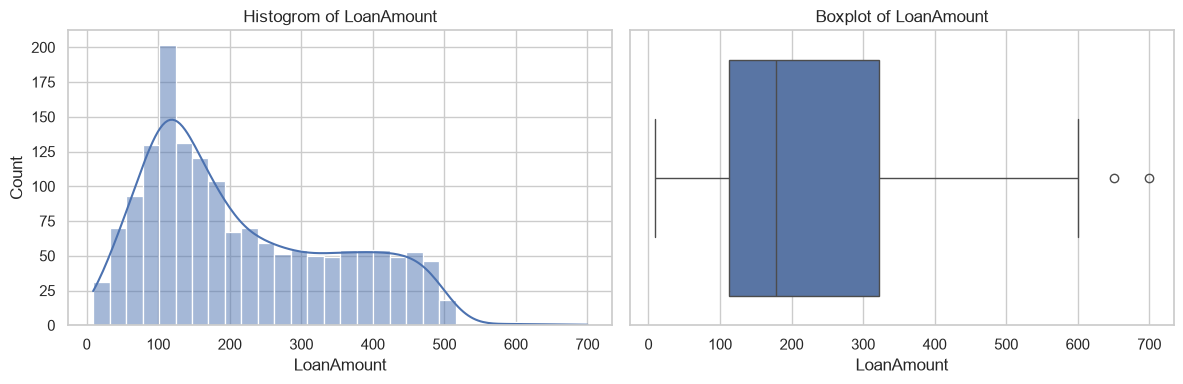

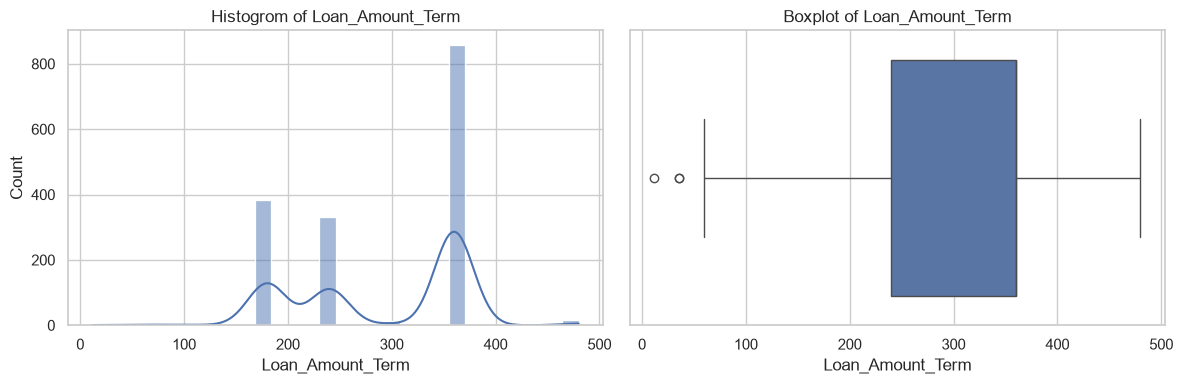

In [24]:
numeric_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']

for col in numeric_cols:
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    sns.histplot(loan[col], kde=True, bins=30)
    plt.title(f'Histogrom of {col}')
    plt.subplot(1,2,2)
    sns.boxplot(x=loan[col])
    plt.title(f"Boxplot of {col}")

    plt.tight_layout()
    plt.show()

In [25]:
for col in ['ApplicantIncome', 'LoanAmount']:
    Q1 = loan[col].quantile(0.25)
    Q3 = loan[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    
    loan[col] = np.where(loan[col] > upper_bound, upper_bound, loan[col])
    loan[col] = np.where(loan[col] < lower_bound, lower_bound, loan[col])

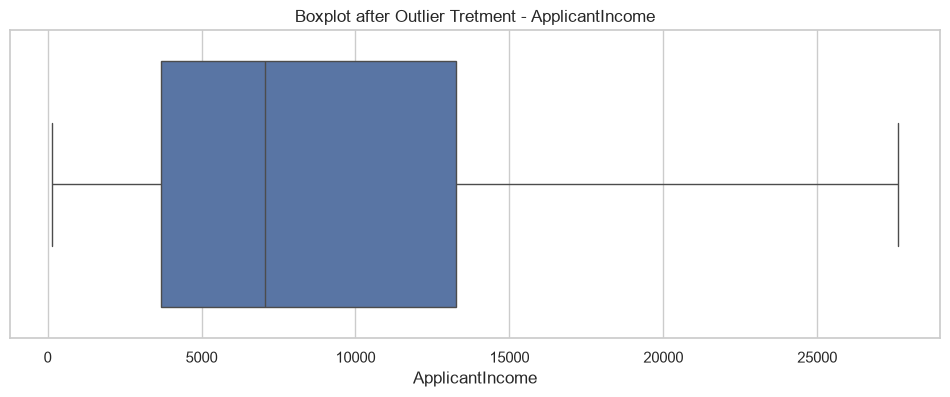

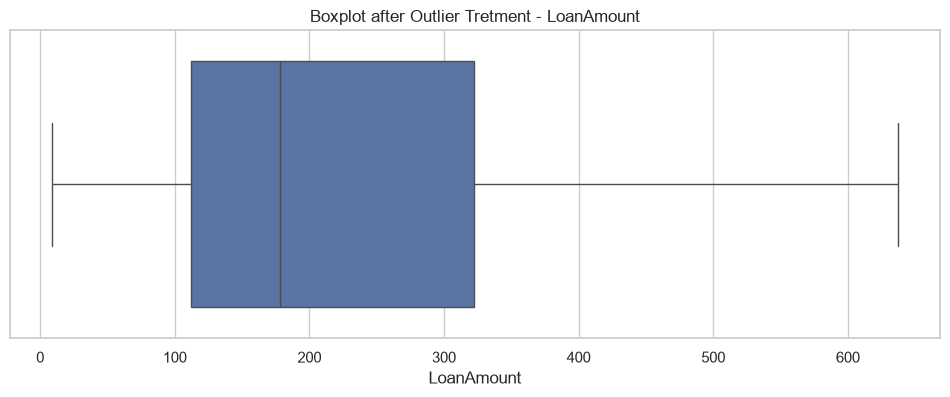

In [26]:
for col in ['ApplicantIncome', 'LoanAmount']:
    plt.figure(figsize=(12,4))
    sns.boxplot(x=loan[col])
    plt.title(f"Boxplot after Outlier Tretment - {col}")
    plt.show()

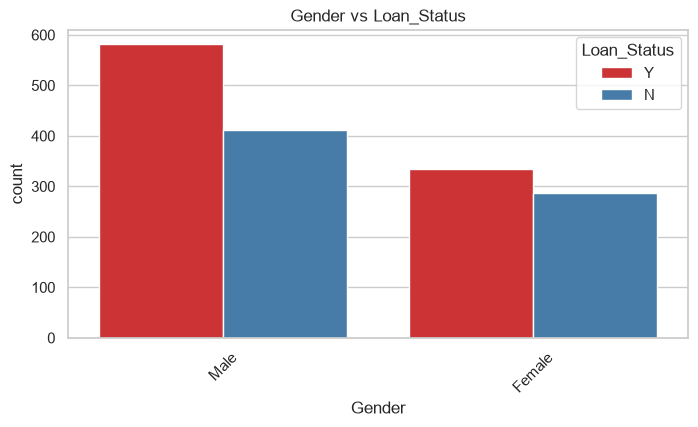

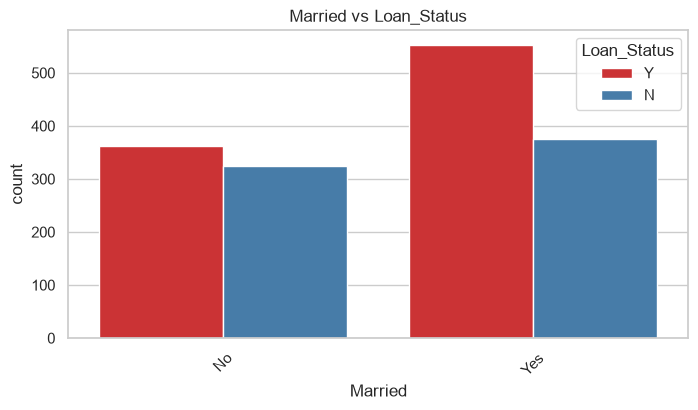

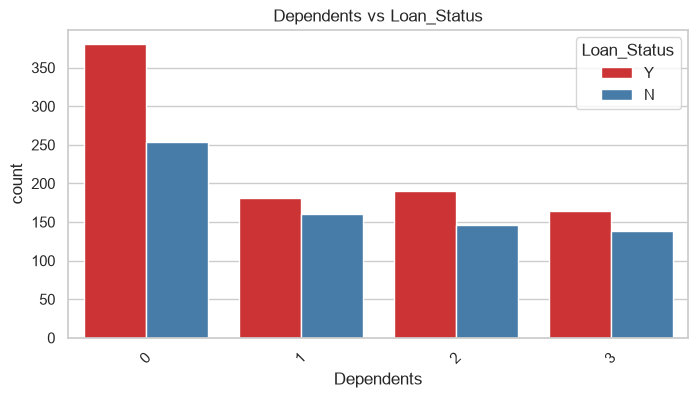

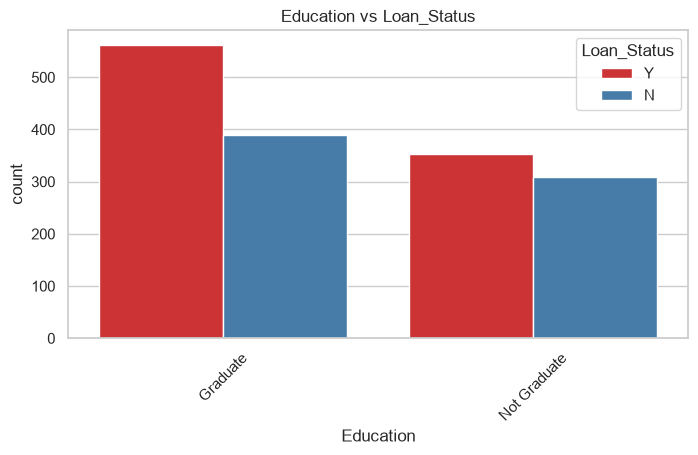

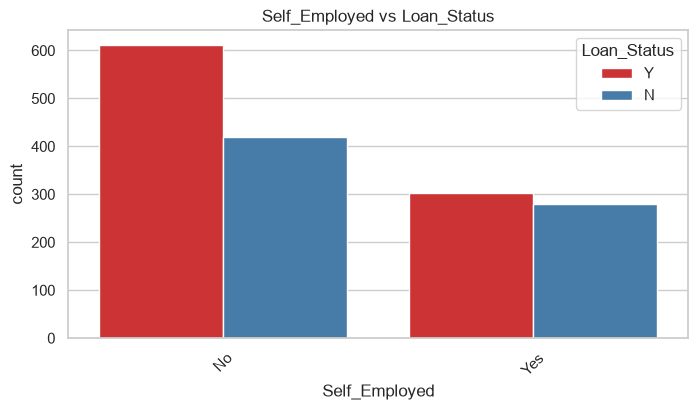

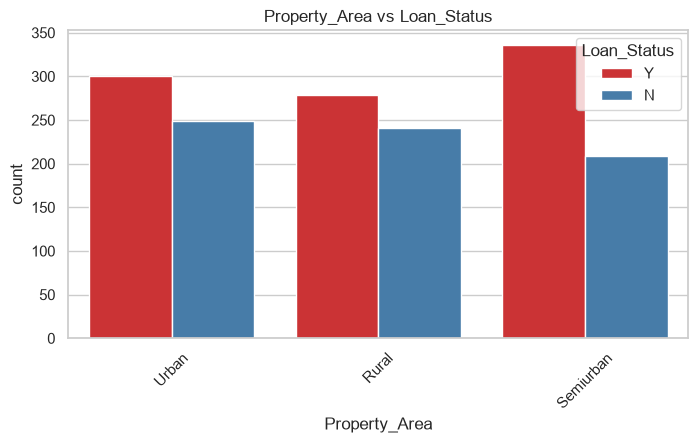

In [27]:
for col in categorical_cols[:-1]:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, hue='Loan_Status', data=loan, palette='Set1')
    plt.title(f"{col} vs Loan_Status")
    plt.xticks(rotation=45)
    plt.show()

C:\Users\Hamza\AppData\Local\Temp\ipykernel_9556\1962644795.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Loan_Status', y=col, data=loan, palette='Set3')


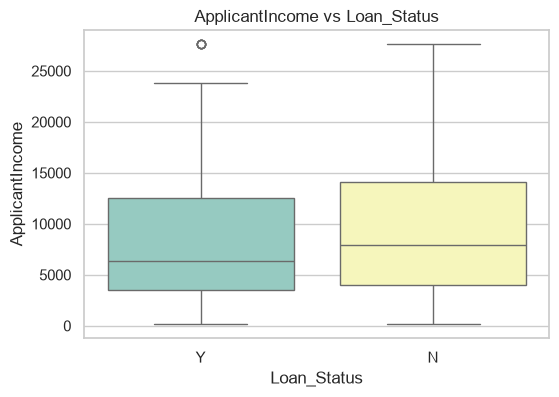

C:\Users\Hamza\AppData\Local\Temp\ipykernel_9556\1962644795.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Loan_Status', y=col, data=loan, palette='Set3')


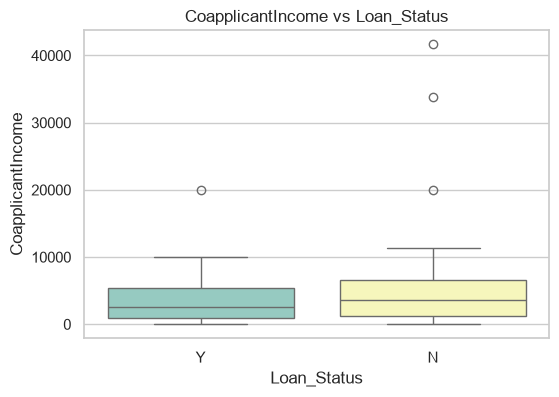

C:\Users\Hamza\AppData\Local\Temp\ipykernel_9556\1962644795.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Loan_Status', y=col, data=loan, palette='Set3')


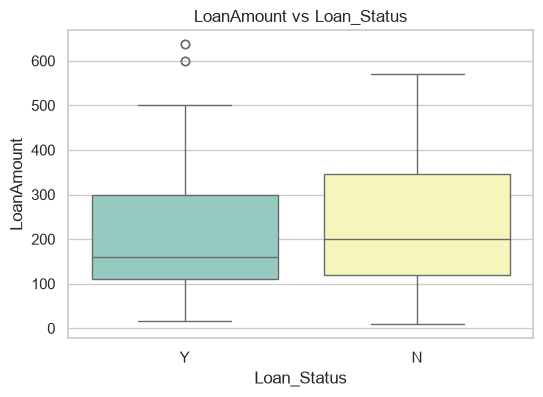

C:\Users\Hamza\AppData\Local\Temp\ipykernel_9556\1962644795.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Loan_Status', y=col, data=loan, palette='Set3')


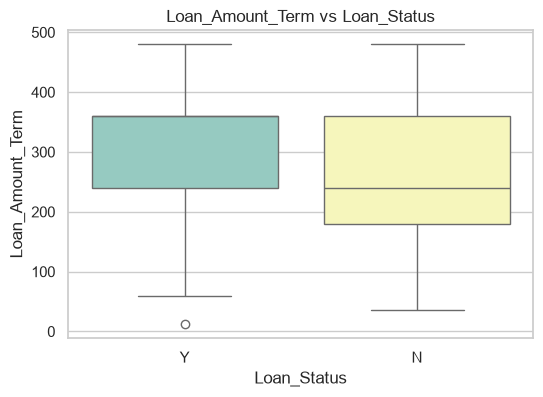

In [28]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Loan_Status', y=col, data=loan, palette='Set3')
    plt.title(f"{col} vs Loan_Status")
    plt.show()

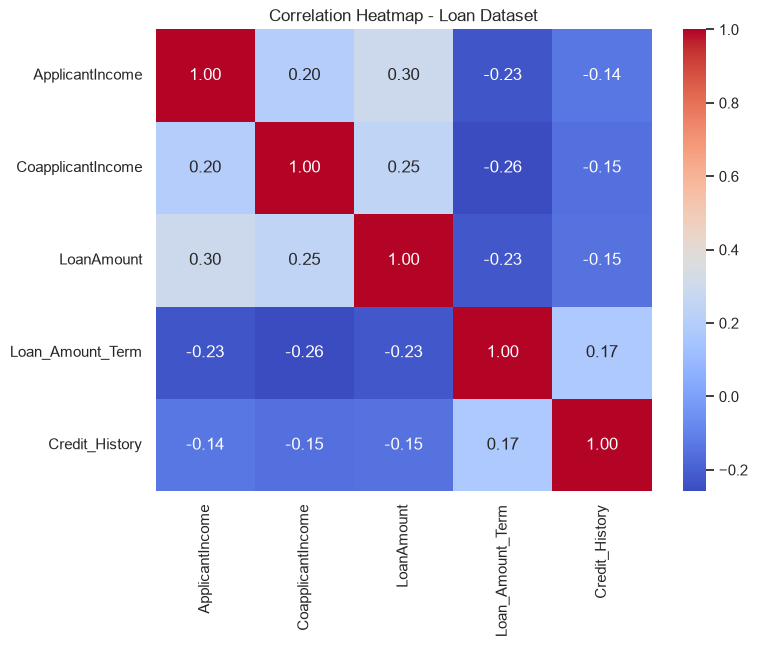

In [29]:
plt.figure(figsize=(8,6))
corr = loan[numeric_cols + ['Credit_History']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap - Loan Dataset')
plt.show()

In [30]:
print(loan.info())
print(loan.head())

<class 'pandas.DataFrame'>
RangeIndex: 1614 entries, 0 to 1613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            1614 non-null   str    
 1   Gender             1614 non-null   str    
 2   Married            1614 non-null   str    
 3   Dependents         1614 non-null   int64  
 4   Education          1614 non-null   str    
 5   Self_Employed      1614 non-null   str    
 6   ApplicantIncome    1614 non-null   float64
 7   CoapplicantIncome  1614 non-null   float64
 8   LoanAmount         1614 non-null   float64
 9   Loan_Amount_Term   1614 non-null   float64
 10  Credit_History     1614 non-null   int64  
 11  Property_Area      1614 non-null   str    
 12  Loan_Status        1614 non-null   str    
dtypes: float64(4), int64(2), str(7)
memory usage: 218.7 KB
None
    Loan_ID Gender Married  Dependents     Education Self_Employed  \
0  LP001002   Male      No           0      Gradu

In [31]:
loan.to_csv('loan_cleaned.csv', index=False)